# Detrending

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import calendar
import ocha_stratus as stratus
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.constants import *

In [167]:
blob_name = "ds-aa-ner-drought/raw/iri/ner_maproom_export_2026-04-25_thresh35 - Sheet1.csv"
df_stats_raw = stratus.load_csv_from_blob(blob_name)
df_stats_raw.columns = ["year"] + [
    calendar.month_abbr[x] for x in [y for y in range(1, 7)] + [8]
]
df_stats_raw["year"] = df_stats_raw["year"].astype(int)

In [168]:
df_stats_raw = df_stats_raw.sort_values("year", ascending=False)

<Axes: xlabel='year'>

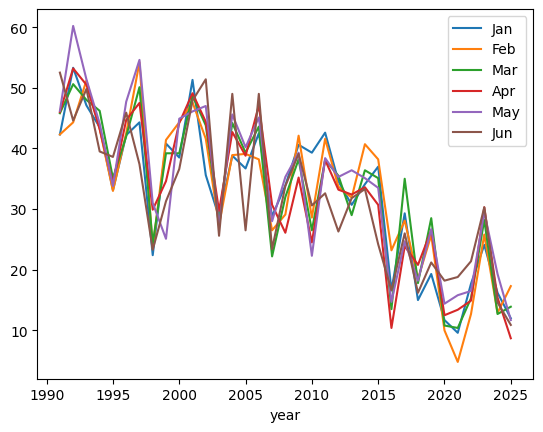

In [169]:
df_stats_raw.drop(columns="Aug").plot(x="year")

In [172]:
from statsmodels.othermod.betareg import BetaModel
import patsy

x_norm = df_stats_raw["year"].values - df_stats_raw["year"].values[0]
n = len(x_norm)


def squeeze(y, n):
    return (y * (n - 1) + 0.5) / n


# design matrix: intercept + x
X = np.column_stack([np.ones(n), x_norm])

df_detrended_beta = df_stats_raw[["year"]].copy()

for col in COLS:
    y = df_stats_raw[col].values / 100.0
    y_sq = squeeze(y, n)

    model = BetaModel(y_sq, X)
    result = model.fit(disp=False)

    trend = result.fittedvalues * 100
    df_detrended_beta[col] = (df_stats_raw[col].values / trend) * trend.mean()

    print(f"{col}: coef={result.params[1]:.4f}, " f"p={result.pvalues[1]:.3e}")

Jan: coef=-0.0407, p=2.804e-12
Feb: coef=-0.0416, p=1.028e-10
Mar: coef=-0.0422, p=2.179e-12
Apr: coef=-0.0455, p=4.210e-16
May: coef=-0.0426, p=4.970e-13
Jun: coef=-0.0390, p=6.489e-12


In [173]:
# residual trend check
for col in COLS:
    r, p = pearsonr(x_norm, df_detrended_beta[col])
    print(f"{col}: r={r:.3f}, p={p:.3f}")

print()
print(df_detrended_beta[COLS].describe().round(3))

Jan: r=-0.150, p=0.391
Feb: r=-0.111, p=0.527
Mar: r=-0.111, p=0.526
Apr: r=-0.120, p=0.493
May: r=-0.122, p=0.487
Jun: r=-0.119, p=0.496

          Jan     Feb     Mar     Apr     May     Jun
count  35.000  35.000  35.000  35.000  35.000  35.000
mean   32.132  32.474  32.572  32.361  33.624  31.734
std     8.544   9.349   9.048   8.472   8.404   7.930
min    14.423   7.271  15.857  13.824  19.021  18.221
25%    27.017  27.325  25.024  26.723  24.908  25.762
50%    32.943  33.317  32.943  32.881  35.971  30.467
75%    38.728  37.548  40.537  38.703  41.222  35.910
max    47.264  49.478  46.872  51.640  47.924  47.586


In [174]:
from scipy.stats import spearmanr

for col in COLS:
    resid = df_detrended_beta[col]
    # Spearman correlation of |residual - mean| against time
    r, p = spearmanr(x_norm, np.abs(resid - resid.mean()))
    print(f"{col}: r={r:.3f}, p={p:.3f}")

Jan: r=0.534, p=0.001
Feb: r=0.408, p=0.015
Mar: r=0.648, p=0.000
Apr: r=0.525, p=0.001
May: r=0.329, p=0.054
Jun: r=0.155, p=0.373


In [175]:
df_detrended_final = df_stats_raw[["year"]].copy()

for col in COLS:
    resid = df_detrended_beta[col].values
    resid_centered = resid - resid.mean()

    abs_resid = np.abs(resid_centered)
    slope_v, intercept_v, *_ = linregress(x_norm, abs_resid)
    fitted_spread = np.clip(intercept_v + slope_v * x_norm, 1e-3, None)

    df_detrended_final[col] = (
        resid_centered / fitted_spread
    ) * abs_resid.mean() + resid.mean()

# verify both mean and variance trend are gone
print("Mean trend:")
for col in COLS:
    r, p = pearsonr(x_norm, df_detrended_final[col])
    print(f"  {col}: r={r:.3f}, p={p:.3f}")

print("\nVariance trend:")
for col in COLS:
    resid = df_detrended_final[col]
    r, p = spearmanr(x_norm, np.abs(resid - resid.mean()))
    print(f"  {col}: r={r:.3f}, p={p:.3f}")

print()
print(df_detrended_final[COLS].describe().round(3))

Mean trend:
  Jan: r=-0.035, p=0.842
  Feb: r=-0.004, p=0.983
  Mar: r=-0.011, p=0.949
  Apr: r=-0.041, p=0.817
  May: r=-0.094, p=0.590
  Jun: r=-0.099, p=0.570

Variance trend:
  Jan: r=0.143, p=0.411
  Feb: r=0.012, p=0.947
  Mar: r=0.093, p=0.595
  Apr: r=0.032, p=0.856
  May: r=0.048, p=0.782
  Jun: r=0.013, p=0.940

          Jan     Feb     Mar     Apr     May     Jun
count  35.000  35.000  35.000  35.000  35.000  35.000
mean   32.234  32.485  32.613  32.475  33.753  31.835
std     8.528   8.975   8.845   8.006   8.300   7.873
min    10.029  11.797   9.397  17.760  17.805  16.547
25%    26.629  26.624  26.409  26.458  26.015  25.937
50%    33.308  33.661  33.459  32.990  36.221  30.321
75%    37.936  37.923  40.319  37.988  41.330  36.554
max    47.131  46.724  44.621  46.390  45.067  47.766


In [176]:
df_detrended_final

,year,Jan,Feb,Mar,Apr,May,Jun
0,2025,24.815346,30.821719,27.693682,22.135256,23.270522,20.653123
1,2024,28.704136,25.280460,25.869307,29.089253,32.681584,25.036865
2,2023,36.399552,38.717861,40.818385,44.943131,45.067276,45.014592
3,2022,28.979365,23.793006,27.226542,27.097168,27.377715,32.457636
4,2021,19.907797,14.710479,21.721449,24.746727,25.722427,28.337025
5,2020,21.452564,19.630957,21.471796,23.067353,23.249819,26.836699
6,2019,28.573454,35.448523,38.148151,37.207954,37.332389,29.757922
7,2018,23.491558,27.164921,26.949320,30.344612,26.307202,22.992786
8,2017,37.254613,36.344446,42.977948,32.754974,33.066301,33.827477
9,2016,23.680839,30.495240,21.274439,17.922395,20.736475,22.119565


<Axes: xlabel='year'>

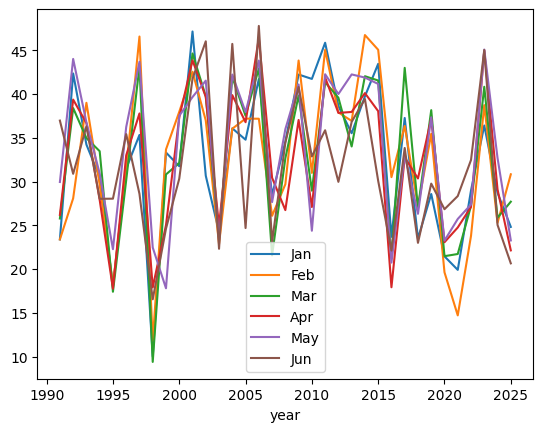

In [177]:
df_detrended_final.set_index("year").plot()

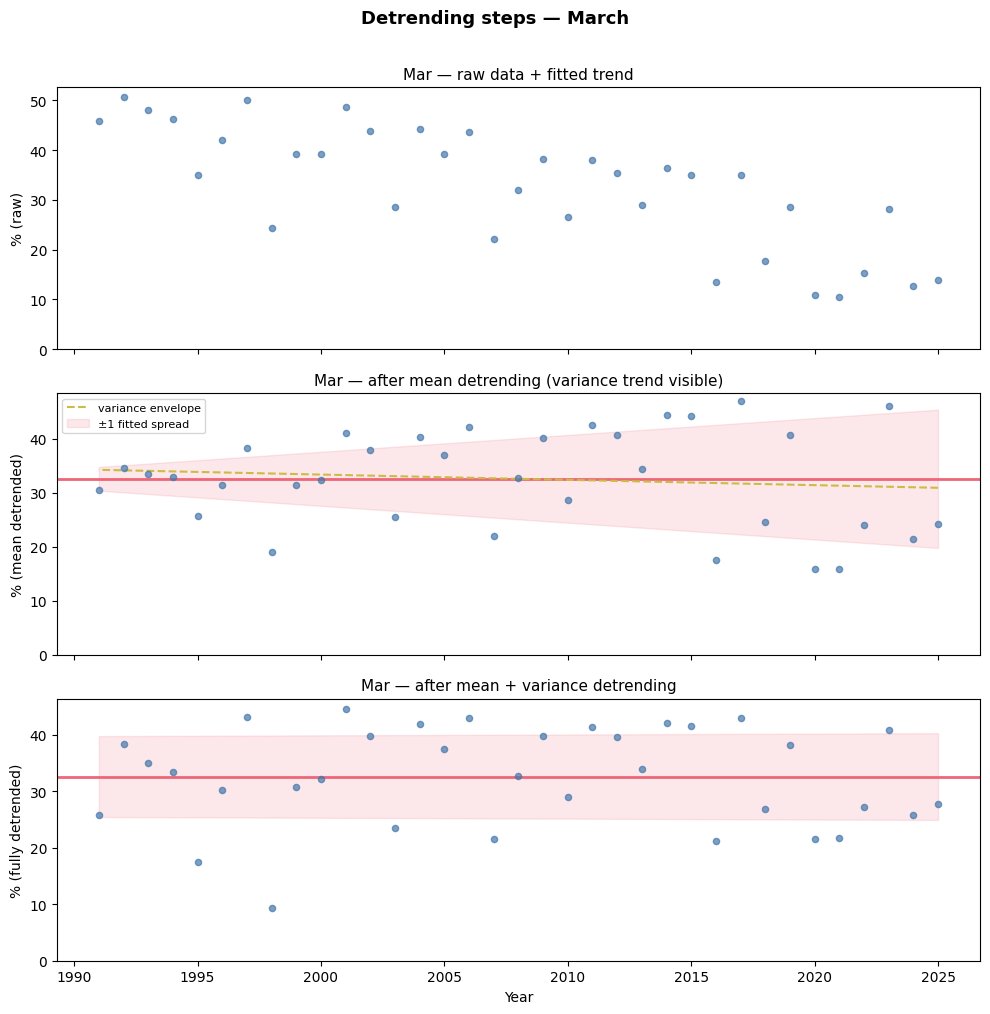

In [178]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

col = "Mar"
years = df_stats_raw["year"].values

# ── raw ────────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(
    years, df_stats_raw[col], s=20, color="#4477AA", alpha=0.7, zorder=3
)

# trend line from beta model
x_plot = np.linspace(0, x_norm.max(), 200)
X_plot = np.column_stack([np.ones(200), x_plot])
# refit just for the line
y_sq = squeeze(df_stats_raw[col].values / 100.0, n)
res = BetaModel(y_sq, np.column_stack([np.ones(n), x_norm])).fit(disp=False)
trend_line = res.predict(X_plot) * 100
ax.plot(years[0] + x_plot, trend_line, color="#EE6677", lw=2)
ax.set_ylabel("% (raw)")
ax.set_title(f"{col} — raw data + fitted trend", fontsize=11)

# ── mean-detrended ─────────────────────────────────────────────────────────────
ax = axes[1]
ax.scatter(
    years, df_detrended_beta[col], s=20, color="#4477AA", alpha=0.7, zorder=3
)
ax.axhline(df_detrended_beta[col].mean(), color="#EE6677", lw=2)

# overlay a linear fit to show residual variance trend
slope_v, intercept_v, *_ = linregress(x_norm, df_detrended_beta[col])
ax.plot(
    years,
    intercept_v + slope_v * x_norm,
    color="#CCBB44",
    lw=1.5,
    ls="--",
    label="variance envelope",
)

# variance envelope (±1 fitted spread)
abs_resid = np.abs(df_detrended_beta[col] - df_detrended_beta[col].mean())
sv, iv, *_ = linregress(x_norm, abs_resid)
spread = np.clip(iv + sv * x_norm, 1e-3, None)
mean_val = df_detrended_beta[col].mean()
ax.fill_between(
    years,
    mean_val - spread,
    mean_val + spread,
    color="#EE6677",
    alpha=0.15,
    label="±1 fitted spread",
)
ax.legend(fontsize=8)
ax.set_ylabel("% (mean detrended)")
ax.set_title(
    f"{col} — after mean detrending (variance trend visible)", fontsize=11
)

# ── fully detrended ────────────────────────────────────────────────────────────
ax = axes[2]
ax.scatter(
    years, df_detrended_final[col], s=20, color="#4477AA", alpha=0.7, zorder=3
)
ax.axhline(df_detrended_final[col].mean(), color="#EE6677", lw=2)

# show flat variance envelope to confirm it's gone
abs_resid_f = np.abs(df_detrended_final[col] - df_detrended_final[col].mean())
sf, if_, *_ = linregress(x_norm, abs_resid_f)
spread_f = np.clip(if_ + sf * x_norm, 1e-3, None)
mean_f = df_detrended_final[col].mean()
ax.fill_between(
    years, mean_f - spread_f, mean_f + spread_f, color="#EE6677", alpha=0.15
)
ax.set_ylabel("% (fully detrended)")
ax.set_title(f"{col} — after mean + variance detrending", fontsize=11)
ax.set_xlabel("Year")

for ax in axes:
    ax.set_ylim(bottom=0)

plt.suptitle(
    "Detrending steps — March", fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("detrending_steps_mar.png", dpi=150, bbox_inches="tight")
plt.show()

In [50]:
df_stats = df_detrended_final.merge(df_stats_iri[["year", "Aug"]])

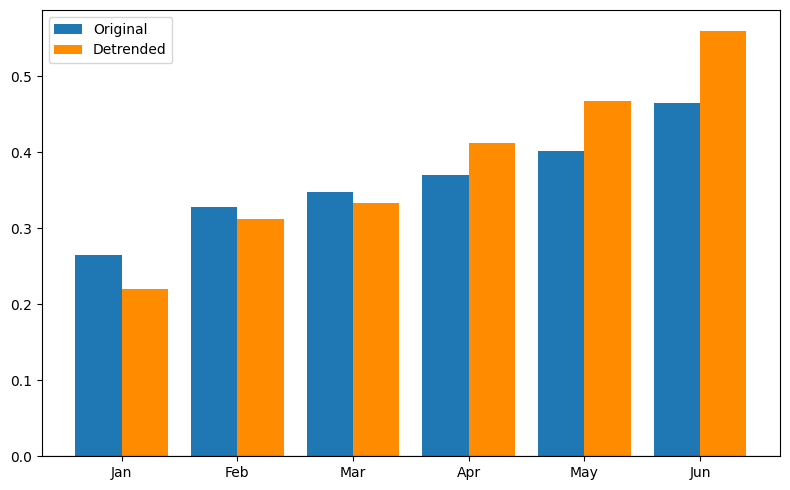

In [83]:
COLS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]

fig, ax = plt.subplots(figsize=(8, 5))

corr1 = -df_stats.corr()["Aug"][COLS]
corr2 = -df_stats_iri.corr()["Aug"][COLS]

x = np.arange(len(COLS))
w = 0.4

ax.bar(x - w / 2, corr2.values, width=w, label="Original")
ax.bar(x + w / 2, corr1.values, width=w, label="Detrended", color="darkorange")


ax.set_xticks(x)
ax.set_xticklabels(COLS)
ax.axhline(0, color="black", lw=0.8)
ax.legend()
plt.tight_layout()
plt.show()

<Axes: >

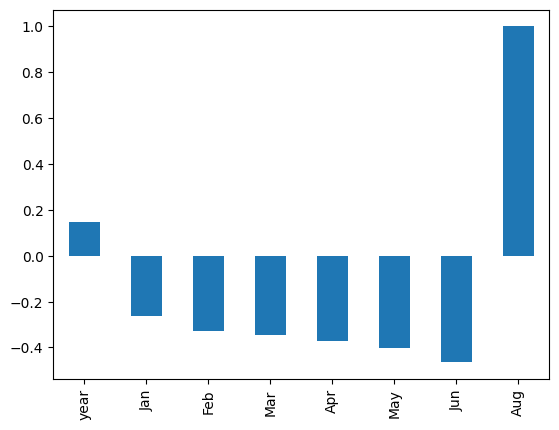

In [65]:
df_stats_iri.corr()["Aug"].plot.bar()

In [57]:
quantiles = np.arange(0.05, 1, 0.05)
quantiles = [round(x, 2) for x in quantiles]

In [62]:
quantiles

[np.float64(0.05),
 np.float64(0.1),
 np.float64(0.15),
 np.float64(0.2),
 np.float64(0.25),
 np.float64(0.3),
 np.float64(0.35),
 np.float64(0.4),
 np.float64(0.45),
 np.float64(0.5),
 np.float64(0.55),
 np.float64(0.6),
 np.float64(0.65),
 np.float64(0.7),
 np.float64(0.75),
 np.float64(0.8),
 np.float64(0.85),
 np.float64(0.9),
 np.float64(0.95)]

In [84]:
mos = [1, 2, 3, 4, 5, 6]

In [147]:
start_year = 1998
end_year = 2025
total_years = end_year - start_year + 1

In [148]:
rp_target = 3.5
n_years_overall_target = int((total_years + 1) / rp_target)

In [149]:
n_years_overall_target

8

In [150]:
actual_rp = (total_years + 1) / n_years_overall_target
actual_rp

3.625

In [151]:
quantiles

[np.float64(0.05),
 np.float64(0.1),
 np.float64(0.15),
 np.float64(0.2),
 np.float64(0.25),
 np.float64(0.3),
 np.float64(0.35),
 np.float64(0.4),
 np.float64(0.45),
 np.float64(0.5),
 np.float64(0.55),
 np.float64(0.6),
 np.float64(0.65),
 np.float64(0.7),
 np.float64(0.75),
 np.float64(0.8),
 np.float64(0.85),
 np.float64(0.9),
 np.float64(0.95)]

In [153]:
dicts = []
df_model = df_stats[df_stats["year"] >= start_year].copy()
n = len(df_model)

# iterate over every possible rank cutoff (1 to n years above threshold)
for n_above in range(0, n + 1):
    for mo in mos:
        col = calendar.month_abbr[mo]
        # top n_above values for this month specifically
        thresh = (
            df_model[col].nlargest(n_above).min() if n_above > 0 else np.inf
        )
        df_model[f"trig_{mo}"] = df_model[col] >= thresh

    consec_cols = []
    for second_mo in mos[1:]:
        first_mo = second_mo - 1
        consec_col = f"trig_{first_mo}_{second_mo}"
        df_model[consec_col] = (
            df_model[f"trig_{first_mo}"] & df_model[f"trig_{second_mo}"]
        )
        consec_cols.append(consec_col)
    df_model["trig_fcast"] = df_model[consec_cols].any(axis=1)
    n_fcast = int(df_model["trig_fcast"].sum())

    for n_below in range(0, n + 1):
        thresh_o = (
            df_model["Aug"].nsmallest(n_below).max()
            if n_below > 0
            else -np.inf
        )
        df_model["trig_obsv"] = df_model["Aug"] <= thresh_o
        n_obsv = int(df_model["trig_obsv"].sum())
        df_model["trig_either"] = (
            df_model["trig_fcast"] | df_model["trig_obsv"]
        )
        n_trig = int(df_model["trig_either"].sum())
        dicts.append(
            {
                "n_above": n_above,
                "n_below": n_below,
                "n_fcast": n_fcast,
                "n_obsv": n_obsv,
                "n_trig": n_trig,
            }
        )

df_qs = pd.DataFrame(dicts).drop_duplicates(subset=["n_fcast", "n_obsv"])

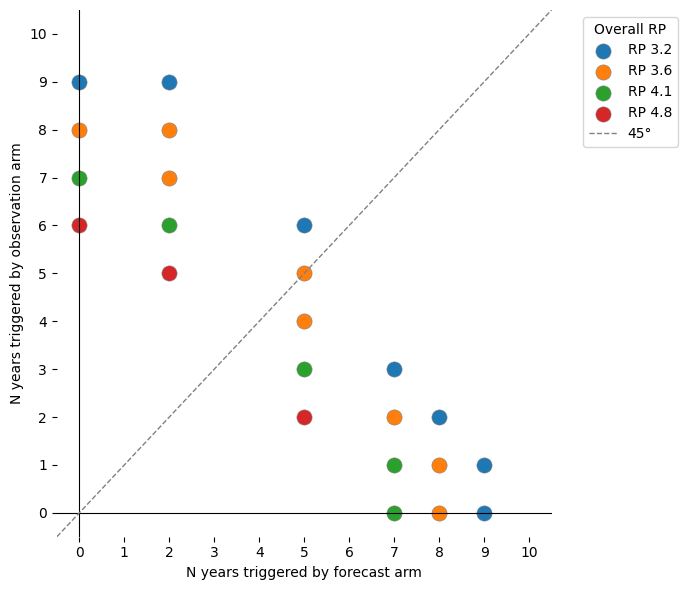

In [154]:
df_qs["rp"] = (len(df_model) + 1) / df_qs["n_trig"]
df_qs_filt = df_qs[df_qs["rp"].between(3, 5)].drop_duplicates(
    subset=["n_fcast", "n_obsv"]
)

# round to nearest 0.5 or just use the exact unique values as categories
rp_vals = sorted(df_qs_filt["rp"].round(1).unique())
cmap = plt.colormaps.get_cmap("tab10")
color_map = {v: cmap(i) for i, v in enumerate(rp_vals)}

fig, ax = plt.subplots(figsize=(7, 6))
for rp_val, group in df_qs_filt.groupby(df_qs_filt["rp"].round(1)):
    ax.scatter(
        group["n_fcast"],
        group["n_obsv"],
        color=color_map[rp_val],
        s=120,
        edgecolors="gray",
        linewidths=0.4,
        label=f"RP {rp_val:.1f}",
    )

ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.axline((0, 0), slope=1, color="gray", lw=1, ls="--", label="45°")
ax.legend(title="Overall RP", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.set_xlabel("N years triggered by forecast arm")
ax.set_ylabel("N years triggered by observation arm")
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.5, 10.5)
ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(1))
plt.tight_layout()
plt.show()

In [159]:
n_fcast_sel = 5
n_obsv_sel = 5

# find the corresponding thresholds
row = df_qs[
    (df_qs["n_fcast"] == n_fcast_sel) & (df_qs["n_obsv"] == n_obsv_sel)
].iloc[0]

n_above = int(row["n_above"])
n_below = int(row["n_below"])

# recompute triggers with those thresholds
df_disp = df_stats.copy()

for mo in mos:
    col = calendar.month_abbr[mo]
    thresh = df_disp[col].nlargest(n_above).min() if n_above > 0 else np.inf
    df_disp[f"trig_{col}"] = df_disp[col] >= thresh

for second_mo in mos[1:]:
    first_mo = second_mo - 1
    fc = calendar.month_abbr[first_mo]
    sc = calendar.month_abbr[second_mo]
    df_disp[f"trig_{fc}_{sc}"] = df_disp[f"trig_{fc}"] & df_disp[f"trig_{sc}"]

thresh_o = df_disp["Aug"].nsmallest(n_below).max() if n_below > 0 else -np.inf
df_disp["trig_fcast"] = df_disp[
    [
        f"trig_{calendar.month_abbr[mos[0]]}_{calendar.month_abbr[mos[1]]}",
        *[
            f"trig_{calendar.month_abbr[m-1]}_{calendar.month_abbr[m]}"
            for m in mos[2:]
        ],
    ]
].any(axis=1)
df_disp["trig_obsv"] = df_disp["Aug"] <= thresh_o
df_disp["trig_either"] = df_disp["trig_fcast"] | df_disp["trig_obsv"]

# ── display 1: per-month and consecutive triggers ─────────────────────────────
month_cols = [f"trig_{calendar.month_abbr[mo]}" for mo in mos]
consec_cols = [
    f"trig_{calendar.month_abbr[m-1]}_{calendar.month_abbr[m]}"
    for m in mos[1:]
]

df_detail = df_disp[df_disp["trig_either"]][
    ["year"] + month_cols + consec_cols
].copy()
df_detail.columns = (
    ["year"]
    + [calendar.month_abbr[mo] for mo in mos]
    + [f"{calendar.month_abbr[m-1]}+{calendar.month_abbr[m]}" for m in mos[1:]]
)


def style_bool(val):
    if val is True:
        return "background-color: crimson; color: white; font-weight: 500"
    return ""


# ── display 1 ─────────────────────────────────────────────────────────────────
df_detail = df_disp[["year"] + month_cols + consec_cols].copy()
df_detail.columns = (
    ["year"]
    + [calendar.month_abbr[mo] for mo in mos]
    + [f"{calendar.month_abbr[m-1]}+{calendar.month_abbr[m]}" for m in mos[1:]]
)

display(
    df_detail.set_index("year")
    .style.map(style_bool)
    .set_caption("Per-month and consecutive triggers")
)

# ── display 2 ─────────────────────────────────────────────────────────────────
df_summary = df_disp[["year", "trig_fcast", "trig_obsv", "trig_either"]].copy()
df_summary.columns = ["year", "forecast", "observation", "either"]

display(
    df_summary.set_index("year")
    .style.map(style_bool)
    .set_caption("Overall forecast / observation triggers")
)

,Jan,Feb,Mar,Apr,May,Jun,Jan+Feb,Feb+Mar,Mar+Apr,Apr+May,May+Jun
year,,,,,,,,,,,
2025,False,False,False,False,False,False,False,False,False,False,False
2024,False,False,False,False,False,False,False,False,False,False,False
2023,False,False,False,True,True,False,False,False,False,True,False
2022,False,False,False,False,False,False,False,False,False,False,False
2021,False,False,False,False,False,False,False,False,False,False,False
2020,False,False,False,False,False,False,False,False,False,False,False
2019,False,False,False,False,False,False,False,False,False,False,False
2018,False,False,False,False,False,False,False,False,False,False,False
2017,False,False,True,False,False,False,False,False,False,False,False


,forecast,observation,either
year,,,
2025,False,False,False
2024,False,False,False
2023,True,False,True
2022,False,True,True
2021,False,False,False
2020,False,False,False
2019,False,False,False
2018,False,False,False
2017,False,False,False


In [161]:
row = df_qs[
    (df_qs["n_fcast"] == n_fcast_sel) & (df_qs["n_obsv"] == n_obsv_sel)
].iloc[0]

n_above = int(row["n_above"])
n_below = int(row["n_below"])

# forecast thresholds per month
thresh_rows = []
for mo in mos:
    col = calendar.month_abbr[mo]
    thresh = df_model[col].nlargest(n_above).min() if n_above > 0 else np.inf
    thresh_rows.append({"month": col, "threshold": thresh, "direction": "≥"})

# observation threshold
thresh_o = df_model["Aug"].nsmallest(n_below).max() if n_below > 0 else -np.inf
thresh_rows.append(
    {"month": "Aug (obs)", "threshold": thresh_o, "direction": "≤"}
)

df_thresh = pd.DataFrame(thresh_rows).set_index("month")

display(
    df_thresh.style.format({"threshold": "{:.2f}"}).set_caption(
        f"Thresholds — forecast arm: top {n_above} years, observation arm: bottom {n_below} years"
    )
)

,threshold,direction
month,,
Jan,43.44,≥
Feb,45.04,≥
Mar,42.92,≥
Apr,43.84,≥
May,42.25,≥
Jun,45.71,≥
Aug (obs),-0.48,≤


In [163]:
from statsmodels.othermod.betareg import BetaModel

n = len(df_stats)
x_norm = df_stats["year"].values - df_stats["year"].values[0]


def squeeze(y, n):
    return (y * (n - 1) + 0.5) / n


# save per-month fit info
fit_info = {}
for col in COLS:
    y = df_stats[col].values / 100.0
    y_sq = squeeze(y, n)
    X = np.column_stack([np.ones(n), x_norm])
    res = BetaModel(y_sq, X).fit(disp=False)

    fit_info[col] = {
        "result": res,
        "intercept": res.params[0],
        "slope": res.params[1],
    }

,detrended_thresh,mean_trend,thresh_2026,thresh_2027
month,,,,
Jan,43.44,32.67,43.25,43.24
Feb,45.04,32.91,45.10,45.10
Mar,42.92,33.02,43.22,43.23
Apr,43.84,32.95,43.22,43.19
May,42.25,34.18,40.72,40.64
Jun,45.71,32.36,43.94,43.84


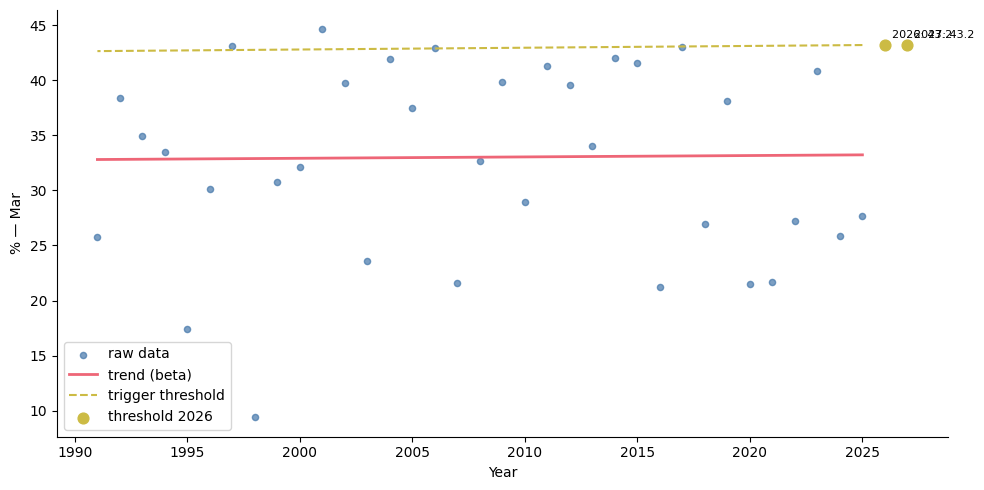

In [165]:
future_years = [2026, 2027]
all_years = df_stats["year"].values
year_start = all_years[0]

thresh_rows = []

for mo in mos:
    col = calendar.month_abbr[mo]
    info = fit_info[col]
    res = info["result"]

    # ── 1. per-year raw threshold ─────────────────────────────────────────
    # detrended threshold (flat in transformed space)
    thresh_detrended = (
        df_model[col].nlargest(n_above).min() if n_above > 0 else np.inf
    )

    # back-transform: multiply by per-year trend, then rescale by mean trend
    x_n = all_years - year_start
    X_hist = np.column_stack([np.ones(len(x_n)), x_n])
    trend = res.predict(X_hist) * 100  # trend in original % scale
    mean_trend = trend.mean()

    # inverse of: detrended = (raw / trend) * mean_trend
    # so: raw = detrended * trend / mean_trend
    thresh_per_year = thresh_detrended * trend / mean_trend

    # ── 2. trendline in original space ────────────────────────────────────
    # already have trend above — this IS the trendline

    # ── 3. future thresholds for 2026 and 2027 ───────────────────────────
    future_thresholds = {}
    for yr in future_years:
        x_fut = np.array([[1, yr - year_start]])
        t_fut = res.predict(x_fut)[0] * 100
        t_raw = thresh_detrended * t_fut / mean_trend
        future_thresholds[yr] = round(t_raw, 2)

    thresh_rows.append(
        {
            "month": col,
            "detrended_thresh": round(thresh_detrended, 2),
            "mean_trend": round(mean_trend, 2),
            **{f"thresh_{yr}": future_thresholds[yr] for yr in future_years},
        }
    )

    # store per-year series back onto df for plotting
    df_stats[f"thresh_raw_{col}"] = thresh_per_year
    df_stats[f"trend_raw_{col}"] = trend

# ── summary table ──────────────────────────────────────────────────────────────
df_thresh_summary = pd.DataFrame(thresh_rows).set_index("month")
display(
    df_thresh_summary.style.format("{:.2f}").set_caption(
        f"Back-transformed thresholds (forecast arm, top {n_above} years)"
    )
)

# ── plot one month as example ──────────────────────────────────────────────────
col = "Mar"
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(
    df_stats["year"],
    df_stats[col],
    s=20,
    color="#4477AA",
    alpha=0.7,
    label="raw data",
)
ax.plot(
    df_stats["year"],
    df_stats[f"trend_raw_{col}"],
    color="#EE6677",
    lw=2,
    label="trend (beta)",
)
ax.plot(
    df_stats["year"],
    df_stats[f"thresh_raw_{col}"],
    color="#CCBB44",
    lw=1.5,
    ls="--",
    label="trigger threshold",
)

# future points
for yr in future_years:
    t_raw = df_thresh_summary.loc[col, f"thresh_{yr}"]
    ax.scatter(
        yr,
        t_raw,
        s=60,
        color="#CCBB44",
        zorder=5,
        label=f"threshold {yr}" if yr == future_years[0] else "",
    )
    ax.annotate(
        f"{yr}: {t_raw:.1f}",
        (yr, t_raw),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_xlabel("Year")
ax.set_ylabel(f"% — {col}")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()